# 05 - Bivariate Analysis: 2D Visualizations

**Milestone 1 — Part 4.B**: Create 2D scatter/density plots for 3 meaningful feature pairs.

## Objectives
- Select 3 feature pairs with meaningful relationships (guided by notebook 04)
- Create scatter plots or density plots for each pair
- Interpret observed patterns and trends

## Expected Outcomes
| Deliverable | Description |
|---|---|
| 3 scatter/density plots | One per feature pair, clearly labeled |
| Trend annotations | Visual or written notes on patterns |
| Discussion paragraph | Interpretation of observed relationships |

---

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

TARGET = "taxvaluedollarcnt"

def dollar_format(x, pos):
    return f'${x:,.0f}'

df = pd.read_csv("zillow_cleaned.csv")
print(f"Shape: {df.shape}")

Shape: (74303, 27)


## Pair 1: `calculatedfinishedsquarefeet` vs `taxvaluedollarcnt`

Rationale: sqft is universally the #1 driver of property value. This will show if the relationship is linear, nonlinear, or has clusters.

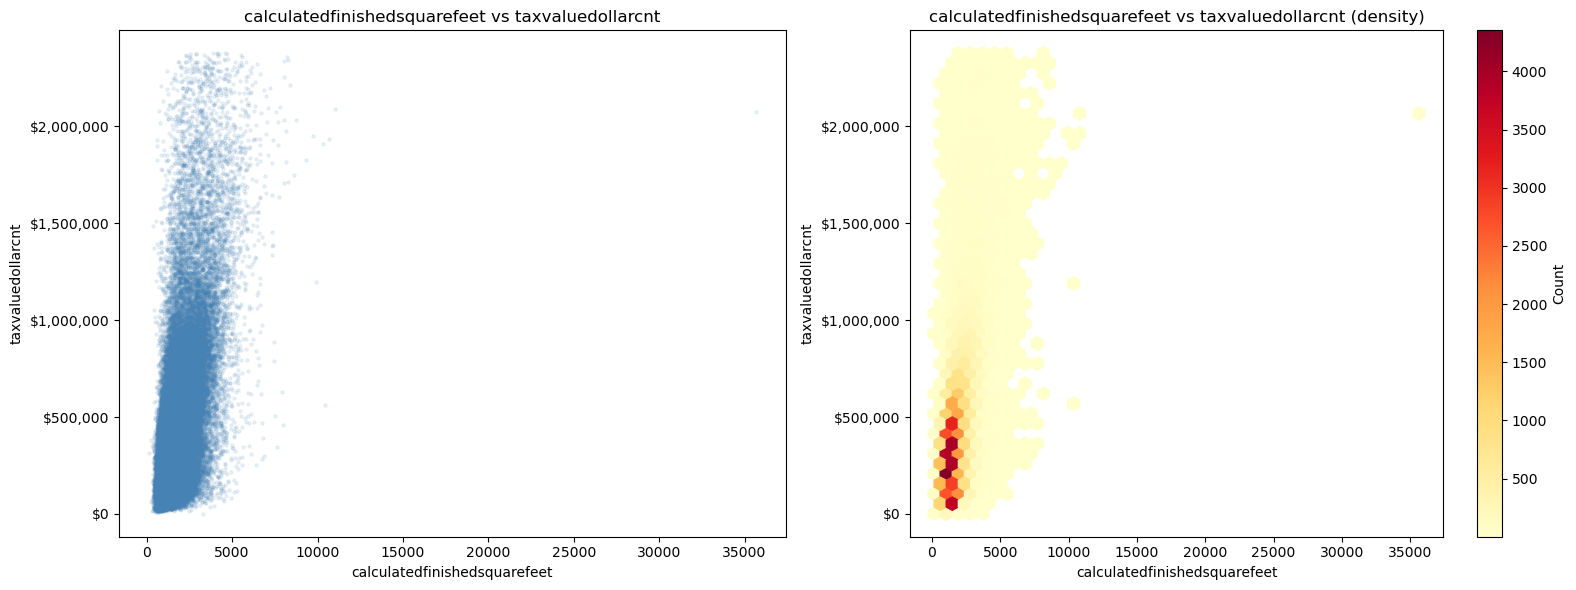

In [14]:
feat_x, feat_y = "calculatedfinishedsquarefeet", TARGET

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(df[feat_x], df[feat_y], alpha=0.1, s=5, color="steelblue")
axes[0].set_xlabel(feat_x)
axes[0].set_ylabel(feat_y)
axes[0].set_title(f"{feat_x} vs {feat_y}")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

# Density plot (hexbin) for a cleaner view
hb = axes[1].hexbin(df[feat_x], df[feat_y], gridsize=40, cmap="YlOrRd", mincnt=1)
axes[1].set_xlabel(feat_x)
axes[1].set_ylabel(feat_y)
axes[1].set_title(f"{feat_x} vs {feat_y} (density)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
plt.colorbar(hb, ax=axes[1], label="Count")

plt.tight_layout()
plt.show()

### Observations — Pair 1

- **Direction**: Clear positive relationship — as square footage increases, tax value increases.
- **Shape**: The relationship is roughly linear for properties under ~3,000 sqft, but the scatter widens significantly above that. This suggests a log or polynomial transform on sqft might improve linearity.
- **Density**: The hexbin plot reveals the vast majority of properties cluster in a tight band between 1,000–2,500 sqft and $100K–$600K. This is the "typical home" zone — the model will learn this relationship most reliably.
- **Outliers**: A few properties with very large sqft (>5,000) show unpredictable tax values — these are likely luxury homes where finish quality, location, and amenities matter more than raw size.
- **Implication**: Square footage is a strong linear predictor for the bulk of data, but additional features are needed to explain variance in larger/luxury properties.

## Pair 2: `yearbuilt` vs `taxvaluedollarcnt`

Rationale: In EDA you found yearbuilt has a bimodal distribution. Plotting it against the target reveals whether newer homes are more valuable and whether the 1920s/1950s peaks show different value bands.

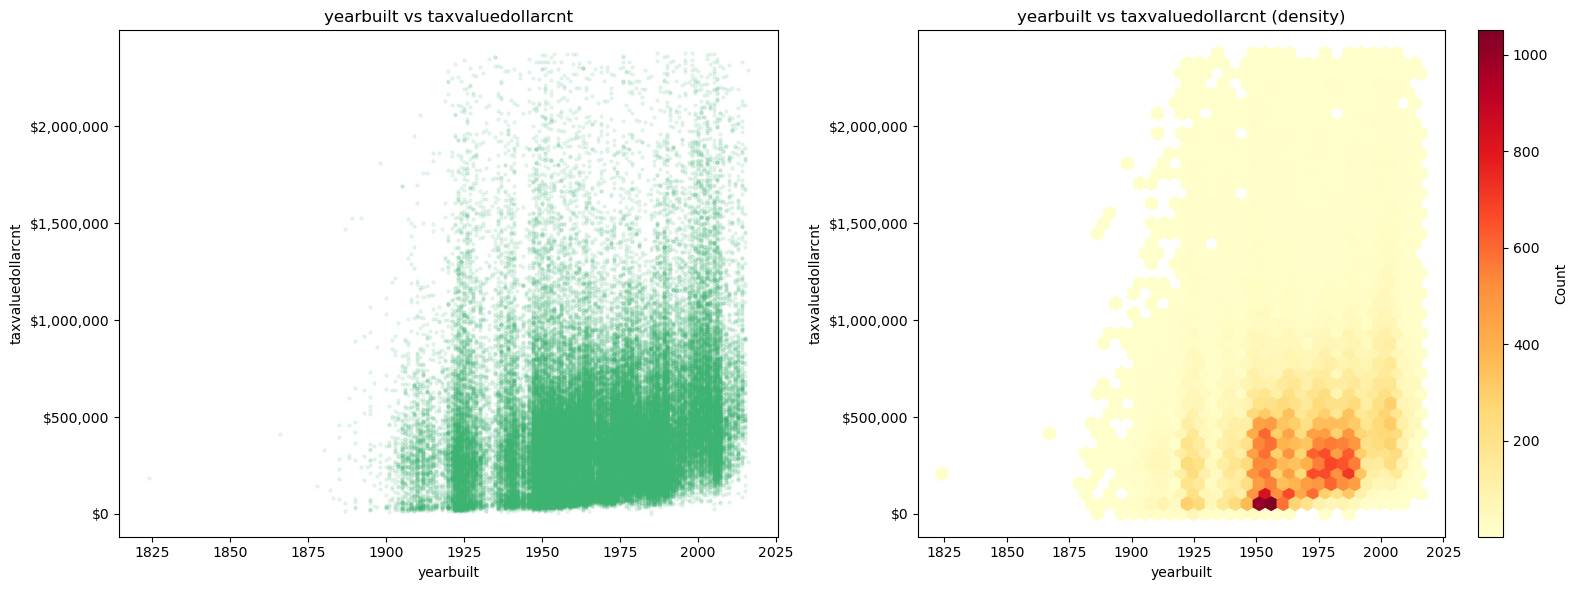

In [15]:
feat_x, feat_y = "yearbuilt", TARGET

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df[feat_x], df[feat_y], alpha=0.1, s=5, color="mediumseagreen")
axes[0].set_xlabel(feat_x)
axes[0].set_ylabel(feat_y)
axes[0].set_title(f"{feat_x} vs {feat_y}")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

hb = axes[1].hexbin(df[feat_x], df[feat_y], gridsize=40, cmap="YlOrRd", mincnt=1)
axes[1].set_xlabel(feat_x)
axes[1].set_ylabel(feat_y)
axes[1].set_title(f"{feat_x} vs {feat_y} (density)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
plt.colorbar(hb, ax=axes[1], label="Count")

plt.tight_layout()
plt.show()

### Observations — Pair 2

- **Direction**: Generally positive — newer homes tend to have higher tax values, but the relationship is much weaker than sqft vs target.
- **Shape**: Not linear. There's a "fan" shape — older homes (pre-1960) have a narrow, lower range of values, while newer homes (post-1980) show a much wider spread. This heteroscedasticity (unequal variance) means yearbuilt alone is a poor predictor.
- **Density**: The hexbin confirms two high-density zones around 1950 and 1980, matching the bimodal distribution found in notebook 02. Properties built around 1955 cluster tightly around $200K–$400K.
- **Notable pattern**: Homes built after ~2000 show the highest tax values on average, but also the widest range — some new homes are assessed very low (possibly condos or small units).
- **Implication**: Year built is useful as a supporting feature but not as a standalone predictor. It may work better as an interaction term (e.g., yearbuilt × sqft) or after binning into age categories.

## Pair 3: `calculatedfinishedsquarefeet` vs `lotsizesquarefeet` (colored by target)

Rationale: This shows whether properties cluster into types (small house on big lot vs big house on small lot) and how that affects value. Using the target as color adds a 3rd dimension.

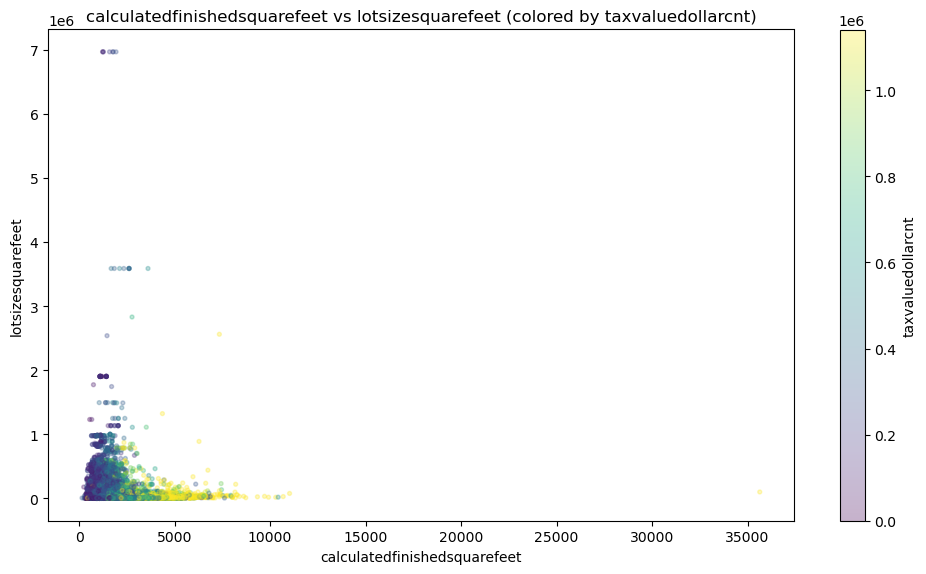

In [16]:
feat_x, feat_y = "calculatedfinishedsquarefeet", "lotsizesquarefeet"

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df[feat_x], df[feat_y],
    c=df[TARGET], cmap="viridis", alpha=0.3, s=8, norm=plt.Normalize(vmin=0, vmax=df[TARGET].quantile(0.95))
)
plt.colorbar(scatter, label=TARGET)
plt.xlabel(feat_x)
plt.ylabel(feat_y)
plt.title(f"{feat_x} vs {feat_y} (colored by {TARGET})")
plt.tight_layout()
plt.show()

### Observations — Pair 3

- **Cluster pattern**: Most properties are tightly packed in the bottom-left corner (small lot, small house). This tells us the dataset is dominated by standard residential properties.
- **Color gradient**: Within the main cluster, brighter colors (higher tax value) tend to appear toward the right side — meaning that finished square footage is a stronger driver of value than lot size. Two properties on the same size lot can have very different values if one has more finished space.
- **Lot size outliers**: There are a few properties with very large lots (>100,000 sqft) but relatively small finished areas — these could be rural or agricultural properties with low tax assessments (dark purple colors confirm this).
- **No strong lot size signal**: Moving upward (larger lot) does not consistently change the color from dark to bright, confirming that lot size alone is a weak predictor compared to finished square footage.
- **Implication**: A ratio feature like `calculatedfinishedsquarefeet / lotsizesquarefeet` (building-to-lot ratio) could capture the "intensity of development" and may be a useful engineered feature in notebook 06.

Overall, these bivariate analyses confirm that calculatedfinishedsquarefeet is the dominant predictor, while yearbuilt and lotsizesquarefeet play supporting roles. The nonlinear patterns and heteroscedasticity observed here suggest that log transforms (explored in notebook 06) and ensemble models (which handle nonlinearity naturally) may outperform simple linear regression.

---
## Discussion 4.B

Brief interpretations of observed patterns or trends:

**Pair 1 (sqft vs target):** There is a clear positive linear relationship between finished square footage and tax value — larger homes are assessed at higher values. However, the relationship becomes noisier above ~3,000 sqft, suggesting that for very large properties, other factors (location, quality) dominate. The density plot confirms that the vast majority of properties cluster in the 1,000–2,500 sqft range with values under $600K.

**Pair 2 (yearbuilt vs target):** Newer homes (post-1980) show a wider range of tax values and generally higher assessments, while older homes (pre-1950) cluster in a tighter, lower value band. This confirms that age is a factor, but the spread for recent construction is large — indicating that year alone is not sufficient for prediction.

**Pair 3 (sqft vs lot size, colored by target):** Most properties cluster in the bottom-left (small lot, small house) with moderate values. High-value properties (yellow/bright) tend to have larger finished square footage but not necessarily larger lots, suggesting that structure size matters more than land size for tax assessment in this market.

---
### Next Notebook → `06_feature_engineering.ipynb`